Connected to Python 3.12.1

[*********************100%***********************]  2 of 2 completed


訓練集：2006-05-22 到 2007-05-22，共 252 天
測試集：2007-05-23 到 2023-12-29，共 4181 天

OLS 求得 hedgeRatio = 1.3945

ADF 統計量：-2.4978
p-value：0.1160
1% 臨界值：-3.4573
5% 臨界值：-2.8734
結論：未達統計顯著性，謹慎使用此策略

Spread 訓練集統計：均值 = 17.1519，標準差 = 1.7235

===== 測試集績效 =====
年化報酬率：3.71%
年化波動率：46.39%
Sharpe Ratio：0.08
最大回撤：-88.13%
交易天數：4181


<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-5c53f3ff4fa5>:213: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing fro

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/pairs_trading_result.png'

C:\Users\flyin\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:96: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\flyin\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:96: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\flyin\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:96: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\flyin\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:96: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\flyin\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:96: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans

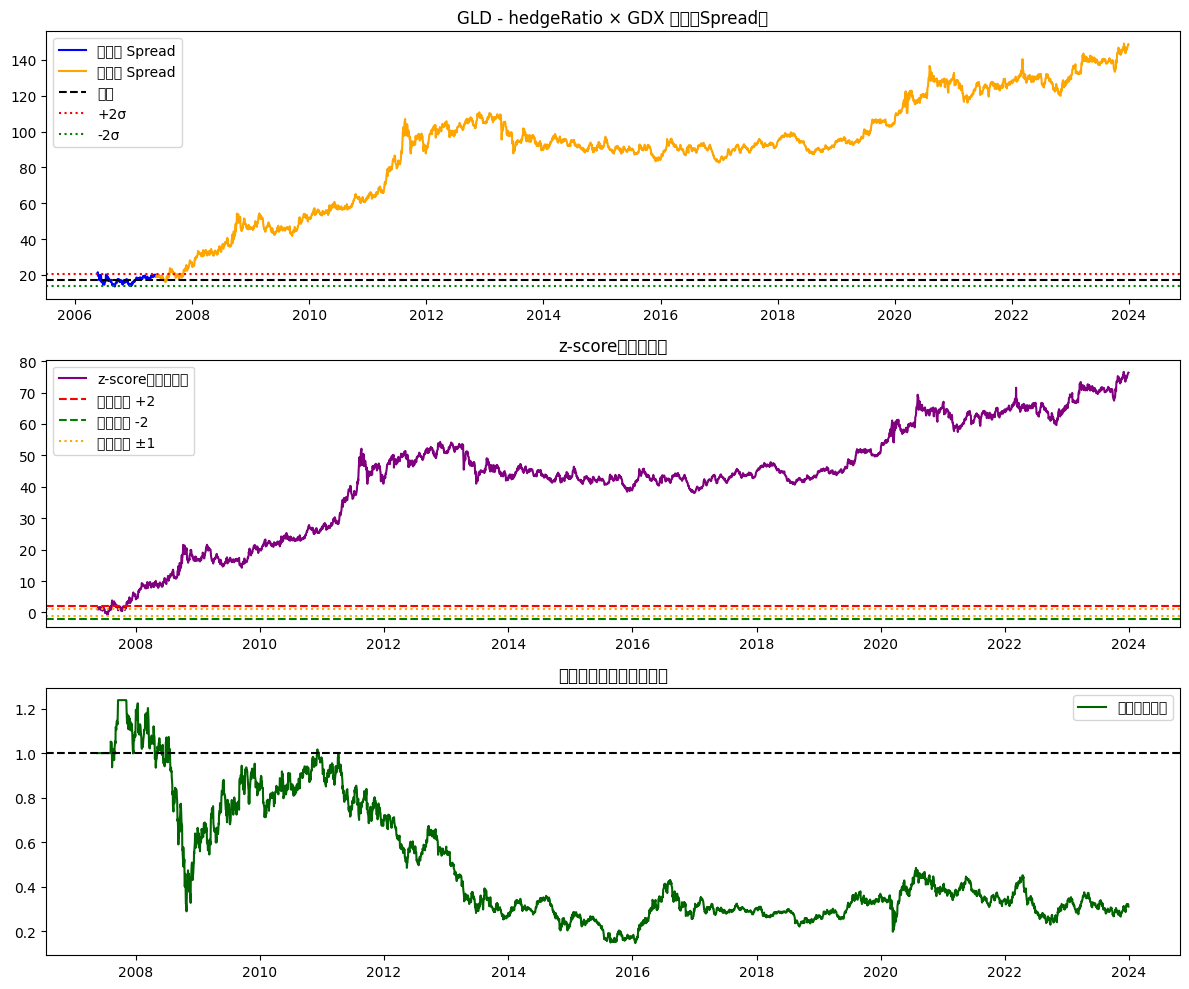

In [ ]:
"""
配對交易策略：GLD vs GDX
根據 Ernest Chan《Quantitative Trading》第 3 章與第 7 章邏輯實作
策略核心：若 GLD 與 GDX 具共整合關係，其價差（spread）是均值回歸的，
可在價差偏離均值時入場，回歸均值時出場獲利。
"""

import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import matplotlib.pyplot as plt


# ============================================================
# 1. 下載資料
# ============================================================

# 下載 GLD 與 GDX 的歷史收盤價
raw = yf.download(["GLD", "GDX"], start="2006-01-01", end="2024-01-01", auto_adjust=True)

# 取出調整後收盤價，去除任何含 NaN 的列
prices = raw["Close"][["GLD", "GDX"]].dropna()

# prices 例子：
#             GLD    GDX
# 2006-05-23  60.1   31.5
# 2006-05-24  59.8   30.9
# ...

# ============================================================
# 2. 切分訓練集與測試集
# ============================================================

# 前 252 個交易日（約一年）作為訓練集，其餘為測試集
train_end = 252
train = prices.iloc[:train_end]
test = prices.iloc[train_end:]

print(f"訓練集：{train.index[0].date()} 到 {train.index[-1].date()}，共 {len(train)} 天")
print(f"測試集：{test.index[0].date()} 到 {test.index[-1].date()}，共 {len(test)} 天")


# ============================================================
# 3. 共整合檢定（Augmented Dickey-Fuller test on spread）
# ============================================================

# 步驟一：用 OLS 回歸求 hedge ratio（避險比率）
# 模型：GLD = hedgeRatio * GDX + 截距
X_train = sm.add_constant(train["GDX"])  # 加入截距項
model = sm.OLS(train["GLD"], X_train).fit()

# hedgeRatio 是 GDX 的係數
# 例如：hedgeRatio = 1.6766，代表每買 1 股 GLD，需放空 1.6766 股 GDX
hedgeRatio = model.params["GDX"]
print(f"\nOLS 求得 hedgeRatio = {hedgeRatio:.4f}")

# 步驟二：建構訓練集的 spread（價差）
# spread = GLD - hedgeRatio * GDX
# spread 若是均值回歸的，就代表兩者有共整合關係
spread_train = train["GLD"] - hedgeRatio * train["GDX"]

# 步驟三：對 spread 進行 ADF 檢定
# ADF 檢定虛無假設：序列有單位根（非定態）
# 若 p-value < 0.05，拒絕虛無假設，代表 spread 是定態（均值回歸）
adf_result = adfuller(spread_train)
print(f"\nADF 統計量：{adf_result[0]:.4f}")
print(f"p-value：{adf_result[1]:.4f}")
print(f"1% 臨界值：{adf_result[4]['1%']:.4f}")
print(f"5% 臨界值：{adf_result[4]['5%']:.4f}")

if adf_result[1] < 0.05:
    print("結論：GLD 與 GDX 具共整合關係，spread 是均值回歸的 ✓")
else:
    print("結論：未達統計顯著性，謹慎使用此策略")


# ============================================================
# 4. 建構完整 spread 與 z-score
# ============================================================

# 對全部資料建構 spread
spread_all = prices["GLD"] - hedgeRatio * prices["GDX"]

# 用訓練集的均值與標準差標準化（避免 look-ahead bias）
# 例如：spread_mean = 2.1，spread_std = 1.8
spread_mean = spread_train.mean()
spread_std = spread_train.std()

# z-score 表示 spread 目前偏離訓練集均值幾個標準差
# z-score 例子：
# 2007-03-01  -2.3  ← 價差遠低於均值，應買入 spread
# 2007-06-01   0.2  ← 接近均值，應平倉
zscore = (spread_all - spread_mean) / spread_std

print(f"\nSpread 訓練集統計：均值 = {spread_mean:.4f}，標準差 = {spread_std:.4f}")


# ============================================================
# 5. 產生交易訊號
# ============================================================

# 訊號邏輯（與書中完全一致）：
# zscore <= -2：買入 spread（做多 GLD，放空 GDX）
# zscore >= +2：賣出 spread（放空 GLD，做多 GDX）
# |zscore| <= 1：平倉

longs = zscore <= -2    # True 的列代表應做多 spread
shorts = zscore >= 2    # True 的列代表應放空 spread
exits = zscore.abs() <= 1  # True 的列代表應平倉

# 建立倉位序列，初始化為 NaN
# positions 的值：+1 = 做多 spread，-1 = 放空 spread，0 = 空倉
positions = pd.Series(np.nan, index=prices.index)

# 逐日填入倉位（模擬實際交易執行順序）
current_position = 0  # 當前持倉
for date in prices.index:
    if longs[date]:
        current_position = 1   # 買入 spread
    elif shorts[date]:
        current_position = -1  # 賣出 spread
    elif exits[date]:
        current_position = 0   # 平倉
    positions[date] = current_position

# 往前填補 NaN（持倉不變直到新訊號）
positions = positions.ffill().fillna(0)


# ============================================================
# 6. 計算策略報酬
# ============================================================

# GLD 與 GDX 的每日報酬率
# ret1 例子：2007-03-02 = 0.012（GLD 當日漲 1.2%）
ret_gld = prices["GLD"].pct_change()
ret_gdx = prices["GDX"].pct_change()

# spread 的日報酬 = 做多 GLD 報酬 - 做空 GDX 報酬
# 注意：做空 GDX 時，GDX 漲代表虧損，故用負號
spread_returns = ret_gld - hedgeRatio * ret_gdx

# 策略日報酬 = 前一日倉位 × 當日 spread 報酬
# 用前一日倉位是為了避免 look-ahead bias（當日訊號下一日才能執行）
strategy_returns = positions.shift(1) * spread_returns

# 只保留測試集的績效評估
strategy_returns_test = strategy_returns.iloc[train_end:]
strategy_returns_test = strategy_returns_test.dropna()


# ============================================================
# 7. 績效指標
# ============================================================

# 累積報酬
cumulative_returns = (1 + strategy_returns_test).cumprod()

# 年化報酬率（假設一年 252 個交易日）
annual_return = strategy_returns_test.mean() * 252

# 年化波動率
annual_vol = strategy_returns_test.std() * np.sqrt(252)

# Sharpe Ratio（假設無風險利率為 0）
sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan

# 最大回撤
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("\n===== 測試集績效 =====")
print(f"年化報酬率：{annual_return:.2%}")
print(f"年化波動率：{annual_vol:.2%}")
print(f"Sharpe Ratio：{sharpe:.2f}")
print(f"最大回撤：{max_drawdown:.2%}")
print(f"交易天數：{len(strategy_returns_test)}")


# ============================================================
# 8. 畫圖
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 圖一：訓練集與測試集的 spread
axes[0].plot(spread_all.iloc[:train_end], label="訓練集 Spread", color="blue")
axes[0].plot(spread_all.iloc[train_end:], label="測試集 Spread", color="orange")
axes[0].axhline(spread_mean, color="black", linestyle="--", label="均值")
axes[0].axhline(spread_mean + 2 * spread_std, color="red", linestyle=":", label="+2σ")
axes[0].axhline(spread_mean - 2 * spread_std, color="green", linestyle=":", label="-2σ")
axes[0].set_title("GLD - hedgeRatio × GDX 價差（Spread）")
axes[0].legend()

# 圖二：z-score 與進出場訊號
axes[1].plot(zscore.iloc[train_end:], label="z-score（測試集）", color="purple")
axes[1].axhline(2, color="red", linestyle="--", label="放空門檻 +2")
axes[1].axhline(-2, color="green", linestyle="--", label="做多門檻 -2")
axes[1].axhline(1, color="orange", linestyle=":", label="平倉門檻 ±1")
axes[1].axhline(-1, color="orange", linestyle=":")
axes[1].set_title("z-score（測試集）")
axes[1].legend()

# 圖三：累積報酬
axes[2].plot(cumulative_returns, label="策略累積報酬", color="darkgreen")
axes[2].axhline(1, color="black", linestyle="--")
axes[2].set_title("策略累積報酬（測試集）")
axes[2].legend()

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/pairs_trading_result.png", dpi=150)
plt.close()

print("\n圖表已儲存為 pairs_trading_result.png")